In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from header_event_analysis import (
    compute_event_metrics_curve,
    evaluate_event_detection,
    filter_rows_by_frame_windows,
    load_inference_folder,
    load_labelled_headers,
    plot_event_metrics_vs_threshold,
    plot_frame_roc_curve,
    plot_match_timeline,
    summarize_event_metrics_by_video
)

FRAME_FILTERS = {
    ("2015-11-25-22-45BMonchengladbach4-2Sevilla", 1): (31396, 166760),
    ("2015-11-25-22-45BMonchengladbach4-2Sevilla", 2): (39875, 181670),
}

# EXCLUDE_MATCHES: set[str] = {
#     "2015-11-25-22-45BMonchengladbach4-2Sevilla",
# }
EXCLUDE_MATCHES = {}

BASE_DIR = Path("/home/aerial/repository/heimdall_net/header_net")
INFERENCE_FOLDER = BASE_DIR / "output" / "2026_03_31_ball-frame_vmae2-base_inference_result" / "test_inference"
# INFERENCE_FOLDER = BASE_DIR / "output" / "2026_03_31_ball-frame_vmae2-base_inference_result" / "test_inference_ep-025"
# INFERENCE_FOLDER = BASE_DIR / "output/2026_04_03_no-ball-detection_vmae2-base_inference_result/test_inference_ep030"
LABEL_DIR = BASE_DIR / "SoccerNet" / "test" / "labelled_header"

THRESHOLD = 0.50
MERGE_GAP = 4
TOL_LEFT = 7
TOL_RIGHT = 8
MATCH_ID = "2016-12-11-22-45ParisSG2-2Nice"
HALF = 1
FRAME_WINDOW = None
THRESHOLD_GRID = np.linspace(0.0, 1.0, 101)

In [2]:
inference_df = filter_rows_by_frame_windows(
    load_inference_folder(INFERENCE_FOLDER),
    FRAME_FILTERS,
    frame_column="frame",
)
gt_df = filter_rows_by_frame_windows(
    load_labelled_headers(LABEL_DIR),
    FRAME_FILTERS,
    frame_column="gt_frame",
)

if EXCLUDE_MATCHES:
    inference_df = inference_df[~inference_df["video_id"].isin(EXCLUDE_MATCHES)].copy()
    gt_df = gt_df[~gt_df["video_id"].isin(EXCLUDE_MATCHES)].copy()

result = evaluate_event_detection(
    inference_df,
    gt_df,
    threshold=THRESHOLD,
    merge_gap=MERGE_GAP,
    tol_left=TOL_LEFT,
    tol_right=TOL_RIGHT
)

overall_metrics = pd.DataFrame([result.metrics])
per_video_metrics = summarize_event_metrics_by_video(result)

display(overall_metrics)
display(per_video_metrics)

NameError: name 'EXCLUDE_MATCHES' is not defined

In [ ]:
selected_gt = result.gt_events[
    (result.gt_events["video_id"] == MATCH_ID) &
    (result.gt_events["half"] == HALF)
]

selected_pred = result.pred_events[
    (result.pred_events["video_id"] == MATCH_ID) &
    (result.pred_events["half"] == HALF)
]

selected_matches = result.matches[
    (result.matches["video_id"] == MATCH_ID) &
    (result.matches["half"] == HALF)
]

display(selected_gt)
display(selected_pred)
display(selected_matches)

,video_id,half,gt_frame,label_path,gt_event_id,matched_pred_event_id,match_status
0,2016-12-11-22-45ParisSG2-2Nice,1,617,/home/aerial/repository/heimdall_net/header_ne...,0,0,tp
1,2016-12-11-22-45ParisSG2-2Nice,1,1877,/home/aerial/repository/heimdall_net/header_ne...,1,<NA>,fn
2,2016-12-11-22-45ParisSG2-2Nice,1,2604,/home/aerial/repository/heimdall_net/header_ne...,2,6,tp
3,2016-12-11-22-45ParisSG2-2Nice,1,7951,/home/aerial/repository/heimdall_net/header_ne...,3,16,tp
4,2016-12-11-22-45ParisSG2-2Nice,1,8057,/home/aerial/repository/heimdall_net/header_ne...,4,17,tp
5,2016-12-11-22-45ParisSG2-2Nice,1,10387,/home/aerial/repository/heimdall_net/header_ne...,5,20,tp
6,2016-12-11-22-45ParisSG2-2Nice,1,10522,/home/aerial/repository/heimdall_net/header_ne...,6,21,tp
7,2016-12-11-22-45ParisSG2-2Nice,1,10636,/home/aerial/repository/heimdall_net/header_ne...,7,23,tp
8,2016-12-11-22-45ParisSG2-2Nice,1,10734,/home/aerial/repository/heimdall_net/header_ne...,8,25,tp
9,2016-12-11-22-45ParisSG2-2Nice,1,11880,/home/aerial/repository/heimdall_net/header_ne...,9,28,tp


,pred_event_id,video_id,half,start_frame,end_frame,peak_frame,peak_prob,n_positive_frames,positive_frames,matched_gt_event_id,match_status
0,0,2016-12-11-22-45ParisSG2-2Nice,1,615,621,618,0.887711,7,"(615, 616, 617, 618, 619, 620, 621)",0,tp
1,1,2016-12-11-22-45ParisSG2-2Nice,1,634,634,634,0.728806,1,"(634,)",<NA>,fp
2,2,2016-12-11-22-45ParisSG2-2Nice,1,1328,1331,1328,0.691323,2,"(1328, 1331)",<NA>,fp
3,3,2016-12-11-22-45ParisSG2-2Nice,1,1435,1436,1435,0.696448,2,"(1435, 1436)",<NA>,fp
4,4,2016-12-11-22-45ParisSG2-2Nice,1,1799,1799,1799,0.669988,1,"(1799,)",<NA>,fp
...,...,...,...,...,...,...,...,...,...,...,...
199,199,2016-12-11-22-45ParisSG2-2Nice,1,71065,71069,71069,0.884291,5,"(71065, 71066, 71067, 71068, 71069)",<NA>,fp
200,200,2016-12-11-22-45ParisSG2-2Nice,1,71817,71817,71817,0.535047,1,"(71817,)",<NA>,fp
201,201,2016-12-11-22-45ParisSG2-2Nice,1,72014,72020,72018,0.796177,6,"(72014, 72015, 72016, 72017, 72018, 72020)",<NA>,fp
202,202,2016-12-11-22-45ParisSG2-2Nice,1,72025,72025,72025,0.630611,1,"(72025,)",<NA>,fp


,pred_event_id,gt_event_id,video_id,half,peak_frame,peak_prob,gt_frame,frame_distance
0,0,0,2016-12-11-22-45ParisSG2-2Nice,1,618,0.887711,617,1
1,6,2,2016-12-11-22-45ParisSG2-2Nice,1,2609,0.756864,2604,5
2,16,3,2016-12-11-22-45ParisSG2-2Nice,1,7949,0.832270,7951,2
3,17,4,2016-12-11-22-45ParisSG2-2Nice,1,8057,0.939734,8057,0
4,20,5,2016-12-11-22-45ParisSG2-2Nice,1,10387,0.944665,10387,0
5,21,6,2016-12-11-22-45ParisSG2-2Nice,1,10523,0.904218,10522,1
6,23,7,2016-12-11-22-45ParisSG2-2Nice,1,10637,0.873793,10636,1
7,25,8,2016-12-11-22-45ParisSG2-2Nice,1,10733,0.808458,10734,1
8,28,9,2016-12-11-22-45ParisSG2-2Nice,1,11880,0.934875,11880,0
9,32,10,2016-12-11-22-45ParisSG2-2Nice,1,12084,0.908299,12083,1


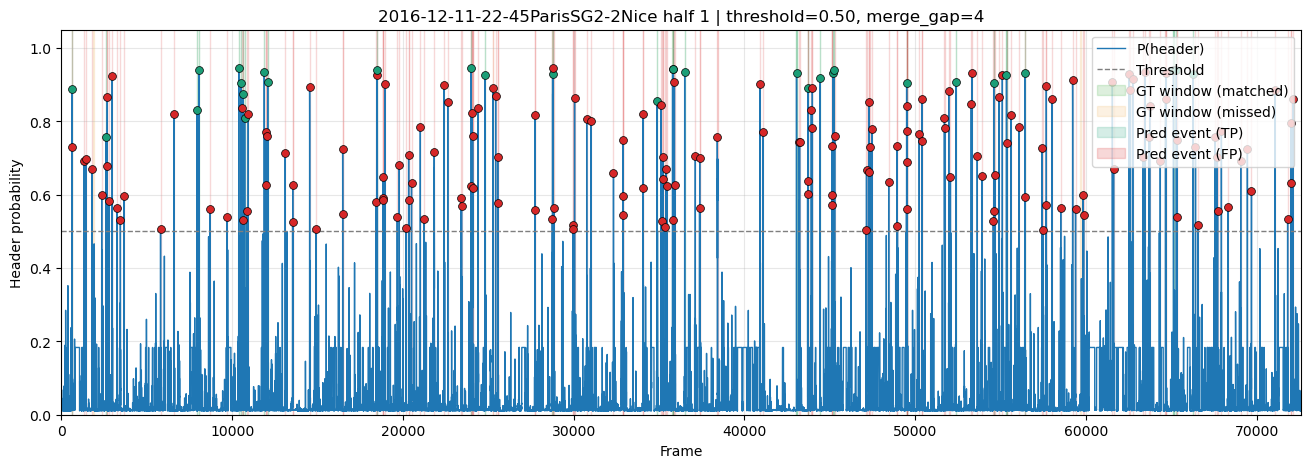

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
plot_match_timeline(
    inference_df,
    result,
    match_id=MATCH_ID,
    half=HALF,
    threshold=THRESHOLD,
    merge_gap=MERGE_GAP,
    tol_left=TOL_LEFT,
    tol_right=TOL_RIGHT,
    frame_window=FRAME_WINDOW,
    ax=ax,
)
plt.show()

In [ ]:
curve_df = compute_event_metrics_curve(
    inference_df,
    gt_df,
    thresholds=THRESHOLD_GRID,
    merge_gap=MERGE_GAP,
    tol_left=TOL_LEFT,
    tol_right=TOL_RIGHT
)

fig, ax = plt.subplots(figsize=(10, 5))
plot_event_metrics_vs_threshold(curve_df, current_threshold=THRESHOLD, ax=ax)
plt.show()

display(curve_df.head())
display(curve_df.tail())

fig, ax = plt.subplots(figsize=(6, 6))
roc_auc = plot_frame_roc_curve(inference_df, ax=ax)
plt.show()

print(f"Frame-level ROC AUC: {roc_auc:.4f}")